In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cleaning Data
#### วิธีทำ
1. Load data
2. Data Reshaping (Pivot Table)
3.  Return Transformation (Daily Log Returns)
4.  Handling Missing Values (ตัดหุ้นที่มีค่าว่างออก)
5.  Standardization & Transpose (ปรับสเกลและสลับมิติให้หุ้นเป็น Samples พร้อมเข้าโมเดล)

In [2]:
# step 1 
df = pd.read_csv('NASDAQ-100/NASDAQ_100_Data_From_2010.csv', sep='\t')
df['Date'] = pd.to_datetime(df['Date'])

# step 2
price_matrix = df.pivot(index='Date', columns='Name', values='Adj Close')

#step 3 
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]

# step 4 
clean_returns = returns_matrix.dropna(axis=1)

# step 5 
scaler = StandardScaler()
# X = scaler.fit_transform(clean_returns)
X = scaler.fit_transform(clean_returns).T


stock_names = clean_returns.columns.tolist()
print(stock_names)
print("จำนวนหุ้น: ", len(stock_names))
print(f"ขนาดของข้อมูล: {X.shape}")

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB', 'BKNG', 'CDNS', 'CERN', 'CHKP', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSX', 'CTAS', 'CTSH', 'DLTR', 'DXCM', 'EA', 'EBAY', 'EXC', 'FAST', 'FISV', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LULU', 'MAR', 'MCHP', 'MDLZ', 'MELI', 'MNST', 'MRVL', 'MSFT', 'MTCH', 'MU', 'NFLX', 'NTES', 'NVDA', 'ORLY', 'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SGEN', 'SIRI', 'SNPS', 'SWKS', 'TCOM', 'TMUS', 'TXN', 'VRSK', 'VRSN', 'VRTX', 'WBA', 'XEL', 'XLNX']
จำนวนหุ้น:  82
ขนาดของข้อมูล: (82, 2942)


# KMeans 
#### ขั้นตอนการทำ
1. หาค่า K ก่อน
   - ใช้วิธี Elbow Method เพื่อหาจุดหักศอก
   - วิธี Silhouette Score วัดความสมบูรณ์ของกลุ่ม
3. กำหนดโมเดลและจำนวน K
4. ให้โมเดลเรียนรู้และจัดกลุ่มข้อมูล
5. นำผลลัพธ์ไปใช้งาน

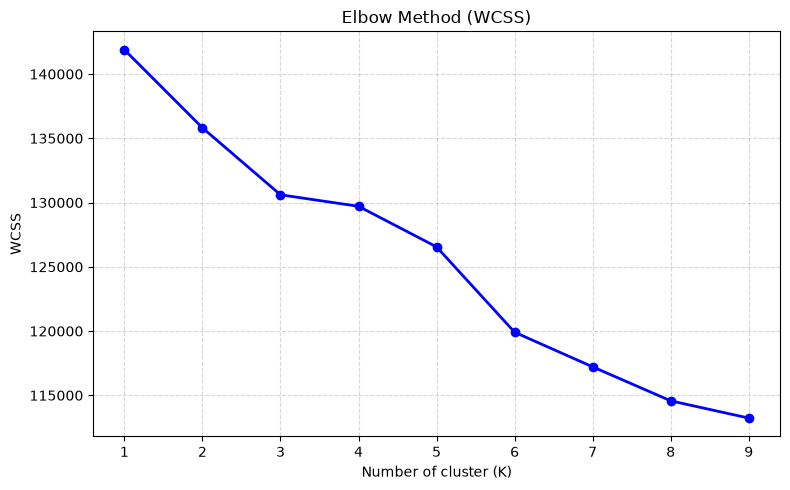

In [11]:
# step 1.1
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)


# กราฟ Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', color='blue', linewidth=2)
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of cluster (K)')
plt.ylabel('WCSS')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

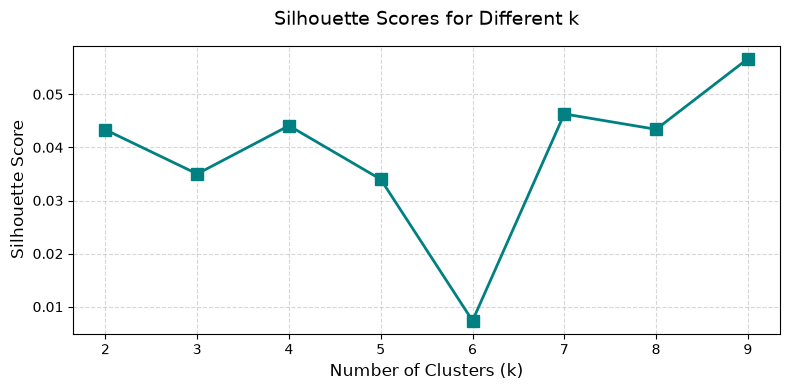

In [16]:
# step 1.2
silhouette_score1 = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_score1.append(score)

plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_score1, marker='s', color='teal', linewidth=2, markersize=8)
plt.title('Silhouette Scores for Different k', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
# step 2 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# step 3
clusters = kmeans.fit_predict(X)

# step 4 
df_result = pd.DataFrame(X)
df_result['Cluster'] = clusters

df_result.head()

,0,1,2,3,4,5,6,7,8,9,...,2933,2934,2935,2936,2937,2938,2939,2940,2941,Cluster
0,0.037505,-0.962919,-0.164020,0.313463,-0.558866,-0.704154,0.729166,-0.386957,-1.009054,2.378476,...,1.627969,-0.536324,0.191923,0.359690,0.178004,0.805989,-0.630636,-0.438713,-1.955847,0
1,0.809301,-0.163727,-1.085771,-0.338519,-0.746613,-0.859384,0.858079,-0.607304,-0.095739,1.513945,...,0.543680,-0.233395,0.122242,-0.150778,0.102999,-0.464928,0.094205,-0.174301,-0.270611,0
2,-0.124616,-0.142292,-0.477391,0.280181,-0.354482,-2.384651,-0.055586,-0.092554,-1.934843,0.929217,...,0.128855,-1.389543,-0.665779,0.479258,-0.098455,0.244978,0.098301,1.674559,0.332167,1
3,-0.440442,-0.219637,-0.082871,-0.151494,0.276618,-0.562780,0.482623,-0.253774,-0.443528,1.044969,...,-0.010316,-0.059060,-0.811511,-0.164799,0.250277,-1.878642,0.987548,-0.420197,-0.888050,2
4,-0.715591,0.068913,0.208200,1.301689,-0.053177,-0.649024,0.576473,0.551448,-0.912298,0.116587,...,-0.353712,-0.505998,-1.027468,-2.406031,0.160860,-0.234956,0.286704,-0.325309,-0.540416,0


## KMeans กับการจัดการข้อมูลด้วย PCA

In [34]:
from sklearn.decomposition import PCA
from matplotlib.patches import Circle

In [35]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X)

In [36]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# step 3
clusters = kmeans.fit_predict(pca_features)

# step 4 
df_result = pd.DataFrame(pca_features)
df_result['Cluster'] = clusters

df_result.head()

,0,1,Cluster
0,6.218342,-1.278859,0
1,5.943435,1.833790,2
2,16.296133,-13.181850,0
3,-10.339350,-12.690749,1
4,9.745656,-0.651393,0


## plot Graph Scatter Plot 

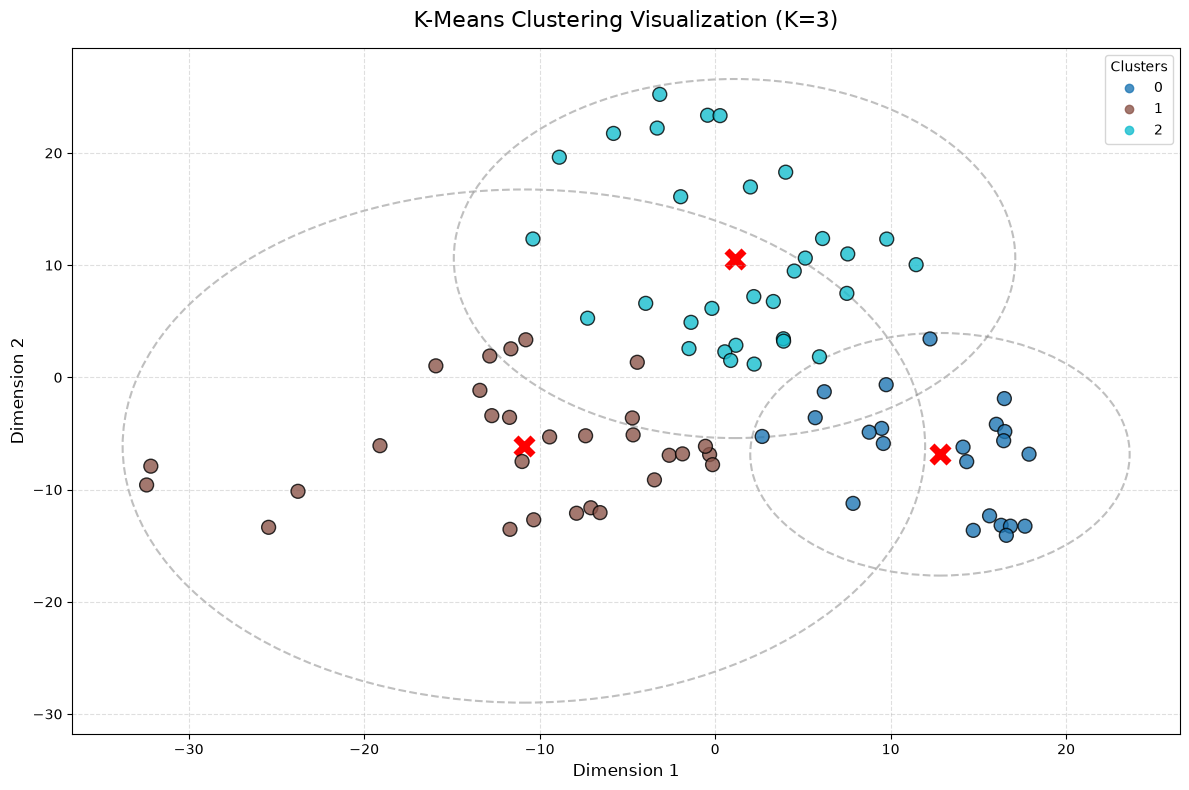

In [37]:
plot_df = pd.DataFrame(pca_features, columns=['Dim1', 'Dim2'], index=stock_names)
plot_df['Cluster'] = clusters

plt.figure(figsize=(12, 8))

ax = plt.gca()

scatter = plt.scatter(
    plot_df['Dim1'],
    plot_df['Dim2'],
    c=plot_df['Cluster'],
    cmap='tab10',
    s=100,
    alpha=0.8,
    edgecolors='black',
    zorder=2
)

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], centroids[:, 1], c='red', marker='X', s=300, label='Centroids', edgecolors='white'
)

# วาดวงกลมล้อมรอบกลุ่ม
for i in range(3):
    points_in_cluster = plot_df[plot_df['Cluster'] == i][['Dim1', 'Dim2']].values

    if len(points_in_cluster) > 0:
        distances = np.linalg.norm(points_in_cluster - centroids[i], axis=1)
        radius = np.max(distances) * 1.05

        # วาดวงกลม
        circle = Circle(
            (centroids[i, 0], centroids[i, 1]), 
            radius, 
            color='gray', 
            fill=False, 
            linestyle='--', 
            linewidth=1.5, 
            alpha=0.5,
            zorder=1 # ให้วงกลมอยู่เป็นพื้นหลัง
        )
        ax.add_patch(circle)

plt.title(f'K-Means Clustering Visualization (K={3})', fontsize=16, pad=15)
plt.xlabel('Dimension 1', fontsize=12)
plt.ylabel('Dimension 2', fontsize=12)

plt.legend(*scatter.legend_elements(), title="Clusters", loc='best')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()